This project documents object annotation and quality review performed on images and video using bounding-box annotations.

In [1]:
import xml.etree.ElementTree as ET

xml_file = "annotations.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

print("XML loaded successfully")

XML loaded successfully


In [2]:
from collections import Counter

label_counts = Counter()

for box in root.findall(".//box"):
    label = box.get("label")
    label_counts[label] += 1

label_counts

Counter({'person': 67, 'vehicle': 18, 'laptop': 4, 'phone': 3})

In [3]:
image_counts = Counter()

for image in root.findall(".//image"):
    image_id = image.get("id")
    boxes = image.findall("./box")

    if boxes:
        image_counts[image_id] += len(boxes)

print("Annotated images:", len(image_counts))
print("Total annotated boxes:", sum(image_counts.values()))

Annotated images: 16
Total annotated boxes: 92


In [4]:
from collections import Counter

# Count bounding boxes for each image
image_box_counts = {}

for image in root.findall(".//image"):
    image_id = image.get("id")
    boxes = image.findall("./box")
    image_box_counts[image_id] = len(boxes)

print("Total images:", len(image_box_counts))
print("Total bounding boxes:", sum(image_box_counts.values()))
print("Average boxes per image:", round(
    sum(image_box_counts.values()) / len(image_box_counts), 2
))
print("Minimum boxes in an image:", min(image_box_counts.values()))
print("Maximum boxes in an image:", max(image_box_counts.values()))

Total images: 16
Total bounding boxes: 92
Average boxes per image: 5.75
Minimum boxes in an image: 2
Maximum boxes in an image: 14


In [5]:
# Show the number of annotations on each image
for image_id, count in image_box_counts.items():
    print(f"Image {image_id}: {count} boxes")

Image 0: 9 boxes
Image 1: 2 boxes
Image 2: 13 boxes
Image 3: 10 boxes
Image 4: 6 boxes
Image 5: 2 boxes
Image 6: 4 boxes
Image 7: 2 boxes
Image 8: 3 boxes
Image 9: 7 boxes
Image 10: 8 boxes
Image 11: 2 boxes
Image 12: 6 boxes
Image 13: 2 boxes
Image 14: 14 boxes
Image 15: 2 boxes


## Annotation Quality Checks

The exported CVAT annotations are reviewed for coordinate validity, image-boundary compliance, and label consistency before further analysis.

In [6]:
# Check every bounding box for basic annotation errors

invalid_boxes = []
out_of_bounds = []
valid_boxes = []

for image in root.findall(".//image"):
    image_id = image.get("id")
    image_width = float(image.get("width"))
    image_height = float(image.get("height"))

    for box in image.findall("./box"):
        label = box.get("label")

        xtl = float(box.get("xtl"))
        ytl = float(box.get("ytl"))
        xbr = float(box.get("xbr"))
        ybr = float(box.get("ybr"))

        # Check that the box has positive width and height
        if xbr <= xtl or ybr <= ytl:
            invalid_boxes.append({
                "image": image_id,
                "label": label,
                "xtl": xtl,
                "ytl": ytl,
                "xbr": xbr,
                "ybr": ybr
            })
            continue

        # Check whether the box extends outside the image boundaries
        if (
            xtl < 0 or
            ytl < 0 or
            xbr > image_width or
            ybr > image_height
        ):
            out_of_bounds.append({
                "image": image_id,
                "label": label,
                "xtl": xtl,
                "ytl": ytl,
                "xbr": xbr,
                "ybr": ybr,
                "image_width": image_width,
                "image_height": image_height
            })
            continue

        # If the box passes both checks, record it as valid
        valid_boxes.append({
            "image": image_id,
            "label": label,
            "xtl": xtl,
            "ytl": ytl,
            "xbr": xbr,
            "ybr": ybr
        })

print("Total bounding boxes:", 92)
print("Valid boxes:", len(valid_boxes))
print("Invalid boxes:", len(invalid_boxes))
print("Out-of-bounds boxes:", len(out_of_bounds))

Total bounding boxes: 92
Valid boxes: 92
Invalid boxes: 0
Out-of-bounds boxes: 0


In [7]:
# Check the labels actually used in the annotations

used_labels = Counter()

for image in root.findall(".//image"):
    for box in image.findall("./box"):
        used_labels[box.get("label")] += 1

print("Labels used in annotations:")
for label, count in used_labels.items():
    print(f"{label}: {count}")

Labels used in annotations:
person: 67
vehicle: 18
laptop: 4
phone: 3


## Annotation Summary

A per-image annotation summary is generated to review class distribution and annotation density across the dataset.

In [8]:
import pandas as pd

# Build a summary showing how many objects of each class appear in every image
summary_rows = []

for image in root.findall(".//image"):
    image_id = image.get("id")

    # Count labels within the current image
    counts = Counter(
        box.get("label")
        for box in image.findall("./box")
    )

    summary_rows.append({
        "Image": image_id,
        "Person": counts.get("person", 0),
        "Vehicle": counts.get("vehicle", 0),
        "Laptop": counts.get("laptop", 0),
        "Phone": counts.get("phone", 0),
        "Total_Annotations": sum(counts.values())
    })

annotation_summary = pd.DataFrame(summary_rows)

# Display the completed summary table
annotation_summary

,Image,Person,Vehicle,Laptop,Phone,Total_Annotations
0,0,3,6,0,0,9
1,1,1,0,1,0,2
2,2,4,9,0,0,13
3,3,9,1,0,0,10
4,4,6,0,0,0,6
5,5,1,0,0,1,2
6,6,2,2,0,0,4
7,7,1,0,1,0,2
8,8,2,0,0,1,3
9,9,7,0,0,0,7


In [9]:
# Calculate overall annotation statistics from the image-level summary

print("Images:", len(annotation_summary))
print("Total annotations:", annotation_summary["Total_Annotations"].sum())
print("Average annotations per image:",
      round(annotation_summary["Total_Annotations"].mean(), 2))

print("\nTotal annotations by class:")
print(annotation_summary[["Person", "Vehicle", "Laptop", "Phone"]].sum())

Images: 16
Total annotations: 92
Average annotations per image: 5.75

Total annotations by class:
Person     67
Vehicle    18
Laptop      4
Phone       3
dtype: int64


In [10]:
import zipfile
import os

# Extract the original images into a folder for visual quality review
zip_file = "source_images.zip"
extract_folder = "source_images"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Source images extracted successfully.")
print("Files found:", len(os.listdir(extract_folder)))

Source images extracted successfully.
Files found: 1


In [11]:
import os

# Inspect the extracted folder structure
for root_dir, folders, files in os.walk("source_images"):
    print("Folder:", root_dir)
    print("Files:", len(files))

    # Show the first few files found
    for file in files[:5]:
        print("  ", file)

    print()

Folder: source_images
Files: 0

Folder: source_images/source_images
Files: 16
   anthony-riera--ZZ7I31c0B8-unsplash.jpg
   divaris-shirichena-P4yr0fvEfsc-unsplash.jpg
   julio-lopez-wPXTrFu_-GY-unsplash.jpg
   qim-manifester-KQ85VO7ofQk-unsplash.jpg
   anthony-lAjjxKJ76bA-unsplash.jpg



In [12]:
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# Folder containing the original images
image_folder = "source_images/source_images"

# Store annotated images here
annotated_images = []

# Process each image from the CVAT XML
for image in root.findall(".//image"):

    image_id = image.get("id")
    image_name = image.get("name")

    image_path = os.path.join(image_folder, os.path.basename(image_name))

    # Skip the image if the original file cannot be found
    if not os.path.exists(image_path):
        print(f"Image not found: {image_name}")
        continue

    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    # Draw every bounding box belonging to this image
    for box in image.findall("./box"):

        label = box.get("label")

        xtl = int(float(box.get("xtl")))
        ytl = int(float(box.get("ytl")))
        xbr = int(float(box.get("xbr")))
        ybr = int(float(box.get("ybr")))

        # Draw bounding box
        draw.rectangle(
            [xtl, ytl, xbr, ybr],
            outline="red",
            width=3
        )

        # Add the object label above the box
        draw.text(
            (xtl, max(0, ytl - 18)),
            label,
            fill="red"
        )

    annotated_images.append((image_id, image_name, img))

print("Annotated images prepared:", len(annotated_images))

Annotated images prepared: 16


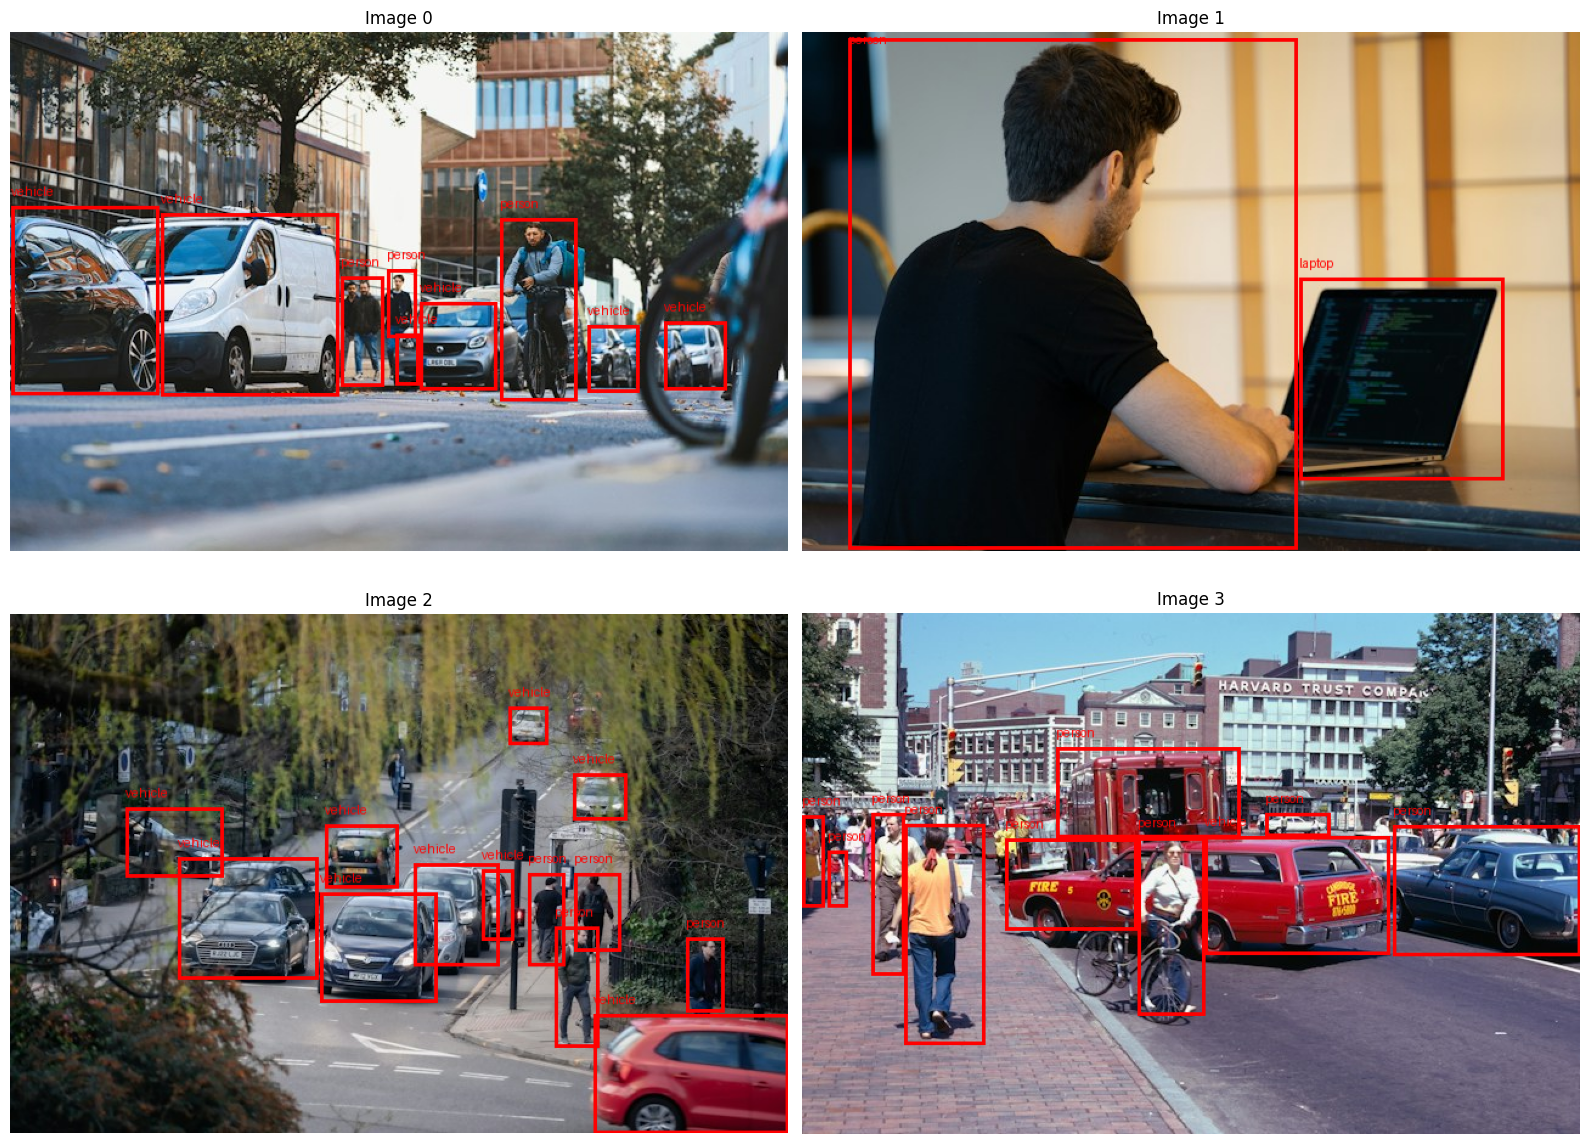

In [13]:
# Display the first 4 annotated images for visual quality review

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (image_id, image_name, img) in zip(axes, annotated_images[:4]):
    ax.imshow(img)
    ax.set_title(f"Image {image_id}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Annotation Quality Summary

The annotated image dataset was reviewed through automated validation and visual quality checks. All bounding boxes passed coordinate and image-boundary validation, and the 16 annotated images were visually reviewed for box placement and label consistency.

In [14]:
# Final quality-control summary for the image annotation dataset

total_images = len(annotation_summary)
total_boxes = annotation_summary["Total_Annotations"].sum()
valid_boxes_count = len(valid_boxes)
invalid_boxes_count = len(invalid_boxes)
out_of_bounds_count = len(out_of_bounds)

print("IMAGE ANNOTATION QUALITY SUMMARY")
print("-" * 35)

print(f"Images reviewed: {total_images}")
print(f"Total bounding boxes: {total_boxes}")
print(f"Valid bounding boxes: {valid_boxes_count}")
print(f"Invalid bounding boxes: {invalid_boxes_count}")
print(f"Out-of-bounds boxes: {out_of_bounds_count}")

print("\nLabels used:")
for label, count in used_labels.items():
    print(f"- {label}: {count}")

print("\nVisual review:")
print("- 16 of 16 images reviewed")
print("- No obvious annotation errors identified")

IMAGE ANNOTATION QUALITY SUMMARY
-----------------------------------
Images reviewed: 16
Total bounding boxes: 92
Valid bounding boxes: 92
Invalid bounding boxes: 0
Out-of-bounds boxes: 0

Labels used:
- person: 67
- vehicle: 18
- laptop: 4
- phone: 3

Visual review:
- 16 of 16 images reviewed
- No obvious annotation errors identified


In [15]:
# Create a compact dataset-level summary for documentation

quality_summary = pd.DataFrame({
    "Metric": [
        "Images reviewed",
        "Total bounding boxes",
        "Valid bounding boxes",
        "Invalid bounding boxes",
        "Out-of-bounds boxes",
        "Visual images reviewed"
    ],
    "Result": [
        total_images,
        total_boxes,
        valid_boxes_count,
        invalid_boxes_count,
        out_of_bounds_count,
        "16 / 16"
    ]
})

quality_summary

,Metric,Result
0,Images reviewed,16
1,Total bounding boxes,92
2,Valid bounding boxes,92
3,Invalid bounding boxes,0
4,Out-of-bounds boxes,0
5,Visual images reviewed,16 / 16


## Exported Annotation Results

The validated annotation summary is exported in CSV and Excel formats for documentation and portfolio use.

In [16]:
# Export the per-image annotation summary
annotation_summary.to_csv(
    "annotation_summary.csv",
    index=False
)

annotation_summary.to_excel(
    "annotation_summary.xlsx",
    index=False
)

print("Annotation summary files created successfully.")

Annotation summary files created successfully.


In [17]:
# Export the overall quality-control results
quality_summary.to_csv(
    "annotation_quality_summary.csv",
    index=False
)

quality_summary.to_excel(
    "annotation_quality_summary.xlsx",
    index=False
)

print("Quality summary files created successfully.")

Quality summary files created successfully.


## Final Portfolio Evidence

Selected visual evidence and a quality-control report are prepared for portfolio presentation. The final materials highlight the annotation workflow, object classes, dataset size, and validation results.

In [19]:
from PIL import Image, ImageDraw, ImageFont
import os
import math

# Output folder for final portfolio evidence
os.makedirs("portfolio_evidence", exist_ok=True)

# Use simple, readable colours for the four annotation classes
label_colors = {
    "person": (220, 60, 60),
    "vehicle": (40, 120, 220),
    "laptop": (40, 160, 90),
    "phone": (150, 80, 190)
}

# Re-create the annotated images with class-specific colours
final_annotated_images = []

for image in root.findall(".//image"):

    image_id = image.get("id")
    image_name = image.get("name")

    image_path = os.path.join(
        "source_images/source_images",
        os.path.basename(image_name)
    )

    if not os.path.exists(image_path):
        continue

    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    for box in image.findall("./box"):

        label = box.get("label")

        xtl = int(float(box.get("xtl")))
        ytl = int(float(box.get("ytl")))
        xbr = int(float(box.get("xbr")))
        ybr = int(float(box.get("ybr")))

        colour = label_colors.get(label, (255, 0, 0))

        draw.rectangle(
            [xtl, ytl, xbr, ybr],
            outline=colour,
            width=max(3, int(min(img.size) / 300))
        )

        draw.text(
            (xtl, max(0, ytl - 20)),
            label,
            fill=colour
        )

    final_annotated_images.append(
        (image_id, image_name, img)
    )

print("Prepared:", len(final_annotated_images), "annotated images")

Prepared: 16 annotated images


In [20]:
# Create a clean overview showing selected annotated images

selected = final_annotated_images[:6]

thumb_width = 500
thumb_height = 350

canvas = Image.new(
    "RGB",
    (thumb_width * 3, thumb_height * 2),
    "white"
)

for index, (image_id, image_name, img) in enumerate(selected):

    img.thumbnail((thumb_width - 20, thumb_height - 20))

    x = (index % 3) * thumb_width
    y = (index // 3) * thumb_height

    paste_x = x + (thumb_width - img.width) // 2
    paste_y = y + (thumb_height - img.height) // 2

    canvas.paste(img, (paste_x, paste_y))

hero_path = "portfolio_evidence/annotation_overview.png"
canvas.save(hero_path, quality=95)

print("Created:", hero_path)

Created: portfolio_evidence/annotation_overview.png


In [21]:
# Create a detailed visual using three annotated images

selected = final_annotated_images[:3]

detail_width = 600
detail_height = 450

canvas = Image.new(
    "RGB",
    (detail_width * 3, detail_height),
    "white"
)

for index, (image_id, image_name, img) in enumerate(selected):

    img.thumbnail((detail_width - 20, detail_height - 20))

    x = index * detail_width

    paste_x = x + (detail_width - img.width) // 2
    paste_y = (detail_height - img.height) // 2

    canvas.paste(img, (paste_x, paste_y))

detail_path = "portfolio_evidence/annotation_detail.png"
canvas.save(detail_path, quality=95)

print("Created:", detail_path)

Created: portfolio_evidence/annotation_detail.png


In [22]:
# Create a simple visual summary of the completed annotation QA

qa_lines = [
    "IMAGE ANNOTATION QUALITY REVIEW",
    "",
    "16 images reviewed",
    "92 total bounding boxes",
    "",
    "Person     67",
    "Vehicle    18",
    "Laptop      4",
    "Phone       3",
    "",
    "Coordinate validation: PASSED",
    "Invalid boxes: 0",
    "Out-of-bounds boxes: 0",
    "",
    "Visual review: 16 / 16",
    "No obvious annotation errors identified"
]

font = ImageFont.load_default()

qa_image = Image.new(
    "RGB",
    (1000, 700),
    "white"
)

draw = ImageDraw.Draw(qa_image)

y = 60

for line in qa_lines:

    draw.text(
        (70, y),
        line,
        fill="black",
        font=font
    )

    y += 38

qa_path = "portfolio_evidence/annotation_QA_summary.png"
qa_image.save(qa_path)

print("Created:", qa_path)

Created: portfolio_evidence/annotation_QA_summary.png


In [24]:
# Install the PDF generation library used for the final report
!pip install reportlab -q

print("ReportLab is ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.4 MB/s eta 0:00:00
ReportLab is ready.


In [25]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    Image as RLImage
)
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

# Create the final PDF report
pdf_path = "portfolio_evidence/Annotation_Quality_Report.pdf"

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=45,
    leftMargin=45,
    topMargin=45,
    bottomMargin=45
)

styles = getSampleStyleSheet()

story = []

story.append(
    Paragraph(
        "Multimodal AI Data Annotation & Quality Review",
        styles["Title"]
    )
)

story.append(
    Paragraph(
        "Image Annotation Quality Report",
        styles["Heading2"]
    )
)

story.append(Spacer(1, 15))

story.append(
    Paragraph(
        "This project documents bounding-box annotation and quality review "
        "performed on a dataset of images containing people and everyday objects. "
        "Annotations were created using CVAT and subsequently reviewed using "
        "Python-based validation and visual quality checks.",
        styles["BodyText"]
    )
)

story.append(Spacer(1, 15))

# Project statistics
data = [
    ["Metric", "Result"],
    ["Images reviewed", "16"],
    ["Total bounding boxes", "92"],
    ["Average annotations per image", "5.75"],
    ["Invalid boxes", "0"],
    ["Out-of-bounds boxes", "0"],
    ["Images visually reviewed", "16 / 16"]
]

table = Table(data, colWidths=[3.2 * inch, 2.2 * inch])

table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.black),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (-1, -1), "Helvetica"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING", (0, 0), (-1, -1), 7),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
    ])
)

story.append(table)

story.append(Spacer(1, 20))

story.append(
    Paragraph(
        "Annotation Classes",
        styles["Heading2"]
    )
)

class_data = [
    ["Class", "Bounding Boxes"],
    ["Person", "67"],
    ["Vehicle", "18"],
    ["Laptop", "4"],
    ["Phone", "3"]
]

class_table = Table(
    class_data,
    colWidths=[3.2 * inch, 2.2 * inch]
)

class_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("ALIGN", (1, 1), (1, -1), "CENTER"),
        ("TOPPADDING", (0, 0), (-1, -1), 7),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
    ])
)

story.append(class_table)

story.append(Spacer(1, 20))

story.append(
    Paragraph(
        "Quality-Control Process",
        styles["Heading2"]
    )
)

story.append(
    Paragraph(
        "The exported CVAT XML was parsed with Python to verify annotation "
        "coordinates and image boundaries. All 92 bounding boxes passed the "
        "coordinate validation checks, with no invalid or out-of-bounds boxes. "
        "All 16 images were subsequently reviewed visually for box placement "
        "and label consistency, with no obvious annotation errors identified.",
        styles["BodyText"]
    )
)

story.append(Spacer(1, 20))

# Add visual evidence
story.append(
    Paragraph(
        "Visual Annotation Evidence",
        styles["Heading2"]
    )
)

story.append(
    RLImage(
        hero_path,
        width=7.0 * inch,
        height=4.7 * inch
    )
)

story.append(Spacer(1, 15))

story.append(
    Paragraph(
        "The examples above show the bounding-box annotations applied to "
        "people and objects in the image dataset.",
        styles["BodyText"]
    )
)

story.append(Spacer(1, 15))

story.append(
    Paragraph(
        "Tools Used",
        styles["Heading2"]
    )
)

story.append(
    Paragraph(
        "CVAT • Python • XML • Pandas • Google Colab",
        styles["BodyText"]
    )
)

story.append(Spacer(1, 15))

story.append(
    Paragraph(
        "Project Outcome",
        styles["Heading2"]
    )
)

story.append(
    Paragraph(
        "The completed dataset contains 92 validated bounding-box annotations "
        "across 16 images and four object classes. The annotation data was "
        "validated programmatically and reviewed visually before being prepared "
        "for portfolio documentation.",
        styles["BodyText"]
    )
)

doc.build(story)

print("Created:", pdf_path)

Created: portfolio_evidence/Annotation_Quality_Report.pdf


In [26]:
# Check all files created for the final portfolio

import os

for root_dir, folders, files in os.walk("portfolio_evidence"):
    print("\nFolder:", root_dir)

    for file in files:
        file_path = os.path.join(root_dir, file)
        size_kb = os.path.getsize(file_path) / 1024
        print(f"  {file} — {size_kb:.1f} KB")


Folder: portfolio_evidence
  annotation_QA_summary.png — 17.2 KB
  annotation_detail.png — 720.3 KB
  Annotation_Quality_Report.pdf — 2510.4 KB
  annotation_overview.png — 1397.2 KB


In [27]:
# Package all final portfolio evidence into one ZIP file

import shutil

zip_path = shutil.make_archive(
    "Multimodal_Annotation_Portfolio_Evidence",
    "zip",
    "portfolio_evidence"
)

print("ZIP created:", zip_path)

ZIP created: /content/Multimodal_Annotation_Portfolio_Evidence.zip
